In [ ]:
Para abrir a camera:  <> Camera Capture

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode


In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

name 'take_photo' is not defined


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

In [ ]:
from IPython.display import Image
try:
  filename = take_photo()
  print('Saved to {}'.format(filename))

  # Show the image which was just taken.
  display(Image(filename))
except Exception as err:
  # Errors will be thrown if the user does not have a webcam or if they do not
  # grant the page permission to access it.
  print(str(err))

<IPython.core.display.Javascript object>

NotAllowedError: Permission denied


pip install ultralytics - YOLO (darknet)

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 872.1/872.1 kB 38.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

modelo = YOLO('yolov8n.pt')
#v8 - versão 8 / n - nano / .pt - 80 classes pré treinada no coco dataset https://docs.ultralytics.com/datasets/detect/coco/#coco-pretrained-models

modelo.predict(source = 'pessoas.jpg', show = True, save = True)  #source = '0' reconhece a camera.

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/pessoas.jpg: 384x640 2 persons, 88.5ms
Speed: 10.9ms preprocess, 88.5ms inference, 680.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted p

##Processamento Digital de Imagens - Processamento de histogramas

Antes de identificar o contorno, o histograma nos auxilia na identificação da quantidade de pixels de uma imagem.

É uma função que mostra a frequencia com que um nível de cinxa aparece na imagem.

A exibição gráfica do histograma para todos os valores de níveis de cinza K providencia uma descrição global de uma imagem.

Quantos pixels eu tenho daquele tom.

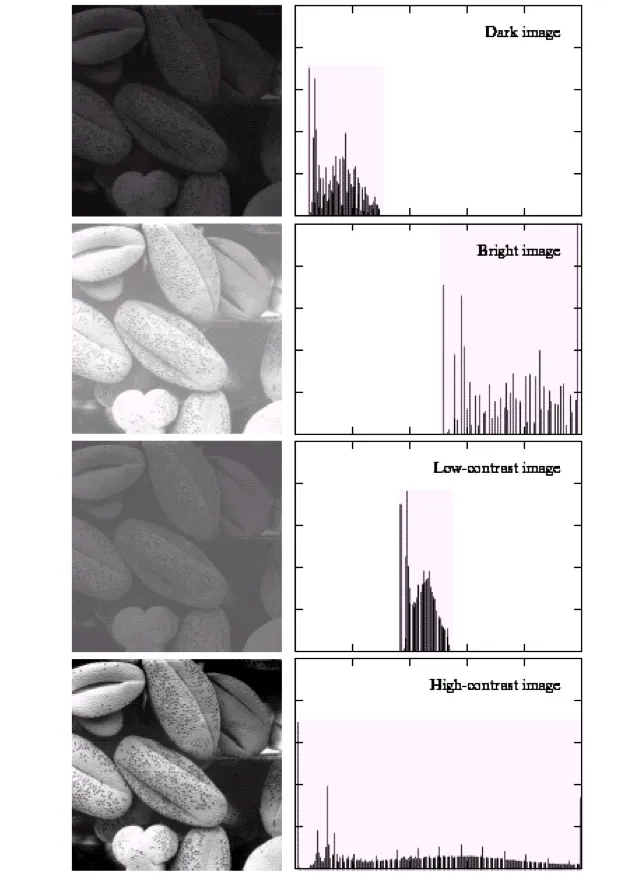

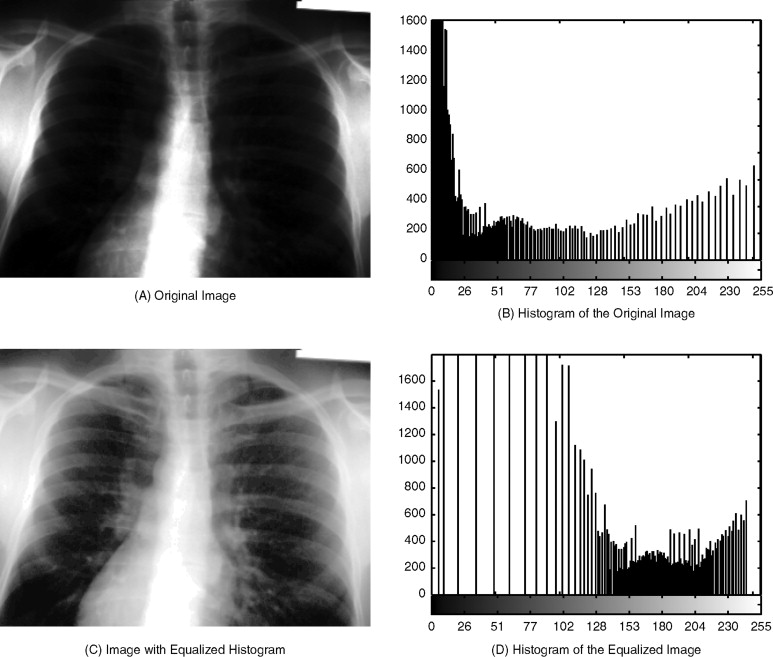


Quando há uma anomalia, é possível identificar através da distorção do padrão das cores dos pixels.

https://medium.com/@gokcenazakyol/what-is-image-enhancement-image-processing-3-32a813087e0a


O ritmo, frequência é diferente de uma pessoa pra outra = Assinatura. O que identifica a assinatura de alguém é o ritmo.


Transformada de Fourier

Integral - área
Derivada - variação - distribuição - equalização

--

*f*(x) = cosx + *i* senx
y = a + *i*b é um número complexo/imaginário = ruído.





Quando utilizar coisa para saúde tem que utilizar programas certificados (matlab ao invés de matplotlib).